In [1]:
# Load the data into variables for experimentation
job_description_path = "api/experiments/job_description.txt"
pdf_text_path = "api/experiments/pdf_text.txt"

try:
    with open(job_description_path, 'r', encoding="utf-8") as f:
        job_text = f.read()

    with open(pdf_text_path, 'r', encoding="utf-8") as f:
        cv_text = f.read()
        
    print("✅ Files loaded successfully!")
    print(f"Job Description length: {len(job_text)} characters")
    print(f"CV Text length: {len(cv_text)} characters")

except FileNotFoundError:
    print("❌ Error: Files not found. Make sure you ran the Django view first!")

✅ Files loaded successfully!
Job Description length: 2694 characters
CV Text length: 4082 characters


In [2]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

lemmatizer = WordNetLemmatizer()

In [3]:
data = pd.DataFrame({
    'job_text': [job_text],
    'cv_text':[cv_text]
    
})

en_stopwords = stopwords.words('english')

data = data.map(lambda text:
             re.sub(r"[^\w\s]", "", text.lower()))

data = data.map(lambda text:
        " ".join([word for word in text.split() if word not in en_stopwords])
        )
data = data.map(lambda text:
         word_tokenize(text)
 
)
data = data.map(lambda tokens:
         [lemmatizer.lemmatize(token) for token in tokens]
 
)

data.head()

,job_text,cv_text
0,"[product, manager, game, domain, product, tel,...","[dor, lazarov, product, manager, 4, year, expe..."


In [4]:
job_dictionary = corpora.Dictionary(data['job_text'])
cv_dictionary = corpora.Dictionary(data['cv_text'])
print(job_dictionary)

Dictionary<208 unique tokens: ['2018', '240', '3', '500', '550']...>


In [5]:
job_doc_term = [job_dictionary.doc2bow(text) for text in data['job_text']]
cv_doc_term = [cv_dictionary.doc2bow(text) for text in data['cv_text']]
print(job_doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 2), (13, 2), (14, 2), (15, 1), (16, 2), (17, 2), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 3), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 2), (42, 2), (43, 2), (44, 1), (45, 1), (46, 2), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 3), (60, 1), (61, 2), (62, 2), (63, 1), (64, 1), (65, 1), (66, 1), (67, 2), (68, 1), (69, 1), (70, 1), (71, 2), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 2), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 2), (89, 1), (90, 1), (91, 2), (92, 1), (93, 1), (94, 1), (95, 1), (96, 3), (97, 2), (98, 1), (99, 1), (100, 1), (101, 1), (102, 3), (103, 2), (104, 1), (105, 1), (106, 1), (107, 2), (108, 1), (109, 1), (110, 1)

In [6]:
num_topics = 2
job_lda_model = gensim.models.LdaModel(corpus = job_doc_term, id2word=job_dictionary, num_topics = num_topics)
cv_lda_model = gensim.models.LdaModel(corpus = cv_doc_term, id2word=cv_dictionary, num_topics = num_topics)
job_lda_model.print_topics(num_topics = num_topics, num_words = 5)

[(0,
  '0.029*"product" + 0.013*"user" + 0.010*"experience" + 0.010*"success" + 0.010*"business"'),
 (1,
  '0.026*"product" + 0.013*"tango" + 0.012*"user" + 0.008*"manager" + 0.008*"live"')]

In [7]:
cv_lda_model.print_topics(num_topics = num_topics, num_words = 5)

[(0,
  '0.031*"product" + 0.012*"user" + 0.011*"development" + 0.009*"management" + 0.008*"agile"'),
 (1,
  '0.032*"product" + 0.016*"user" + 0.015*"development" + 0.010*"experience" + 0.009*"manager"')]

In [8]:
job_lsi_model = gensim.models.LsiModel(corpus = job_doc_term, id2word=job_dictionary, num_topics = num_topics)

In [9]:
cv_lsi_model = gensim.models.LsiModel(corpus = cv_doc_term, id2word=cv_dictionary, num_topics = num_topics)

In [10]:
job_lsi_model.print_topics(num_topics = num_topics, num_words = 15)

[(0,
  '0.532*"product" + 0.222*"user" + 0.177*"tango" + 0.133*"live" + 0.133*"success" + 0.133*"manager" + 0.133*"experience" + 0.133*"business" + 0.089*"b2c" + 0.089*"impact" + 0.089*"define" + 0.089*"decision" + 0.089*"million" + 0.089*"join" + 0.089*"market"')]

In [11]:
cv_lsi_model.print_topics(num_topics = num_topics, num_words = 15)

[(0,
  '0.595*"product" + 0.255*"user" + 0.227*"development" + 0.142*"manager" + 0.142*"experience" + 0.142*"management" + 0.113*"telaviv" + 0.113*"team" + 0.113*"education" + 0.113*"feature" + 0.113*"agile" + 0.085*"year" + 0.085*"across" + 0.085*"analytics" + 0.085*"sport"')]

In [12]:
coherence_values = []
model_list = []

min_topics = 5
max_topics = 11

for num_topics_i in range(min_topics,max_topics + 1):
    model = gensim.models.LsiModel(job_doc_term, num_topics = num_topics_i, id2word = job_dictionary, random_seed= 0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts = data['job_text'], dictionary = job_dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

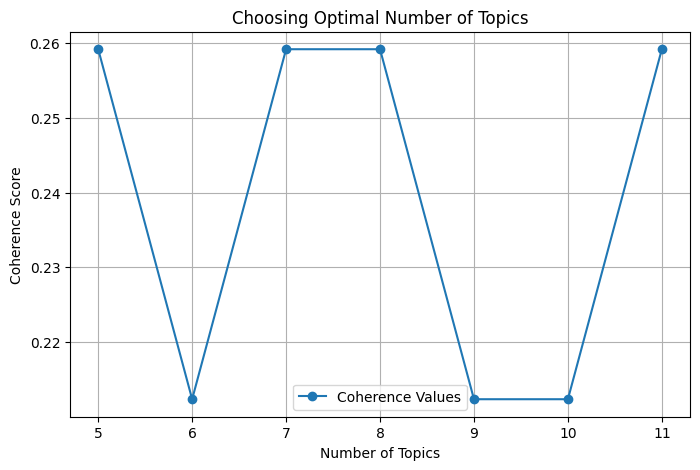

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(min_topics, max_topics + 1), coherence_values, marker='o')

plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.legend(['Coherence Values'], loc='best') 
plt.title('Choosing Optimal Number of Topics')
plt.grid(True)
plt.show()

In [21]:
final_n_topics = 15
lsamodel_f = gensim.models.LsiModel(job_doc_term, num_topics = final_n_topics, id2word = job_dictionary)
print(lsamodel_f.print_topics(num_topics = final_n_topics, num_words = 15))

[(0, '0.532*"product" + 0.222*"user" + 0.177*"tango" + 0.133*"live" + 0.133*"business" + 0.133*"success" + 0.133*"manager" + 0.133*"experience" + 0.089*"domain" + 0.089*"define" + 0.089*"feature" + 0.089*"impact" + 0.089*"global" + 0.089*"join" + 0.089*"livestreaming"')]
